In [1]:
import scanpy as sc
import pandas as pd
import squidpy as sq
import seaborn as sns
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: 

In [2]:
key_celltype = "broad_celltypes"


In [5]:
DATA_PREPARED=True
DATA_PREPARED_T=True


In [6]:
if not DATA_PREPARED:
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_10ad_spatial.h5ad')
else:
   #adata=sc.read_h5ad('/nfs/team361/ls34/adata_mm_spatial_prepped.h5ad')
    adata=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_eczema_spatial_prepped.h5ad')

try:
    adata.obs["NICHE_NAMES"] = adata.obs["niche_name"]
except:
    adata
    
adata  

AnnData object with n_obs × n_vars = 197483 × 1032
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'Sanger patient ID', 'Drug', 'Responder', 'Timepoint', 'Site_status', 'info_id', 'sample', 'niche_name', 'lvl1', 'lvl0', 'veryfine_celltypes_new5', 'veryfine_celltypes_new5_incprolif', 'veryfine_celltypes', 'fine_celltypes_new', 'mod_celltypes_new', 'broad_celltypes_new', 'Site_status_binary', 'fine_celltypes', 'broad_celltypes', 'n_counts', 'n_genes', 'inflow_cell_type', 'inflow_biological_batch_ID', 'inflow_slice_ID', 'inflow_signaling_activity', 'leiden_res0.8', 'leiden_res0.5', 'NICHE_NAMES', 'spatial_niche', 'key_celltype_new'
    uns: 'NICHE_NAMES_colors', 'de_leiden', 'inflow_biological_batch_ID_colors', 'inflow_cell_type_colors',

In [7]:
1

1

# supp fig a

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


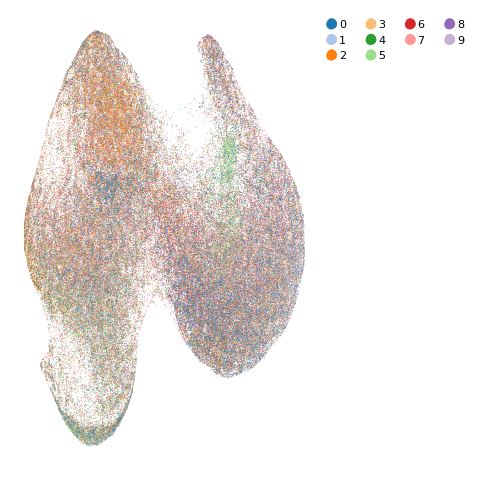

In [8]:
sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(5, 5))


n_batches = adata.obs["info_id"].nunique()
color_palette = sns.color_palette("tab20", n_colors=n_batches)

info_id_colors = {
    str(i): mcolors.to_hex(c) for i, c in enumerate(color_palette)
}

adata.uns["info_id_colors"] = list(info_id_colors.values())

adata.obs["info_id"] = (
    adata.obs["info_id"]
        .astype("category")
        .cat.codes
        .astype(str)
)


ax = sc.pl.umap(
    adata,
    color=["info_id"],
    s=1,
    legend_fontsize=8,
    show=False,
    title="",
)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    fontsize=8,
    ncol=4,
    bbox_to_anchor=(1, 1),
    loc="upper left",
    frameon=False,
    scatterpoints=3,
    title="",
)

plt.tight_layout()
plt.savefig("figures/batch_extrinsic.pdf", bbox_inches="tight")
plt.show()

sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(12, 12))


In [9]:
RES=0.5
if not DATA_PREPARED:
    sc.pl.umap(adata,  
               color=[f'leiden_res{RES}', "NICHE_NAMES"],
               s=20,
               legend_loc="on data",
               legend_fontsize=18)


In [10]:
if not DATA_PREPARED:
    RENAME = {'0': "Epidermis_mid",
     '1': "Neuromuscular",
     '2': "Epidermis_mid",# "Epidermis_basal",
     '3': "Mac_T_cDC2",# "Large blood vessel+muscle",
     '4': "Stroma",
     '5':  "Epidermis_mid",# "Stroma",
     '6': "Epidermis_mid", #"Mac_rich",
     '7':  "Perivascular", #"Stroma_deep",
     '8': "Stroma", #"Epidermis inflamm",
     '9':  "T_DC",# "T_cDC rich",
     '10':  "Epidermis_basal", # "Small lood vessel",
     '11': "Epidermis_late", #"n mid",
     '12':  "Blood vessel",
              "13": "Sweat gland",
              "14":  "Blood vessel",
             }
    adata.obs["spatial_niche"] = adata.obs[f'leiden_res{RES}'].map(RENAME)
    sc.pl.umap(adata,  
           color=[f'spatial_niche', "NICHE_NAMES"],
           s=20,
           legend_loc="on data",
           legend_fontsize=18,
          legend_fontoutline=2)



# fig 2b

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


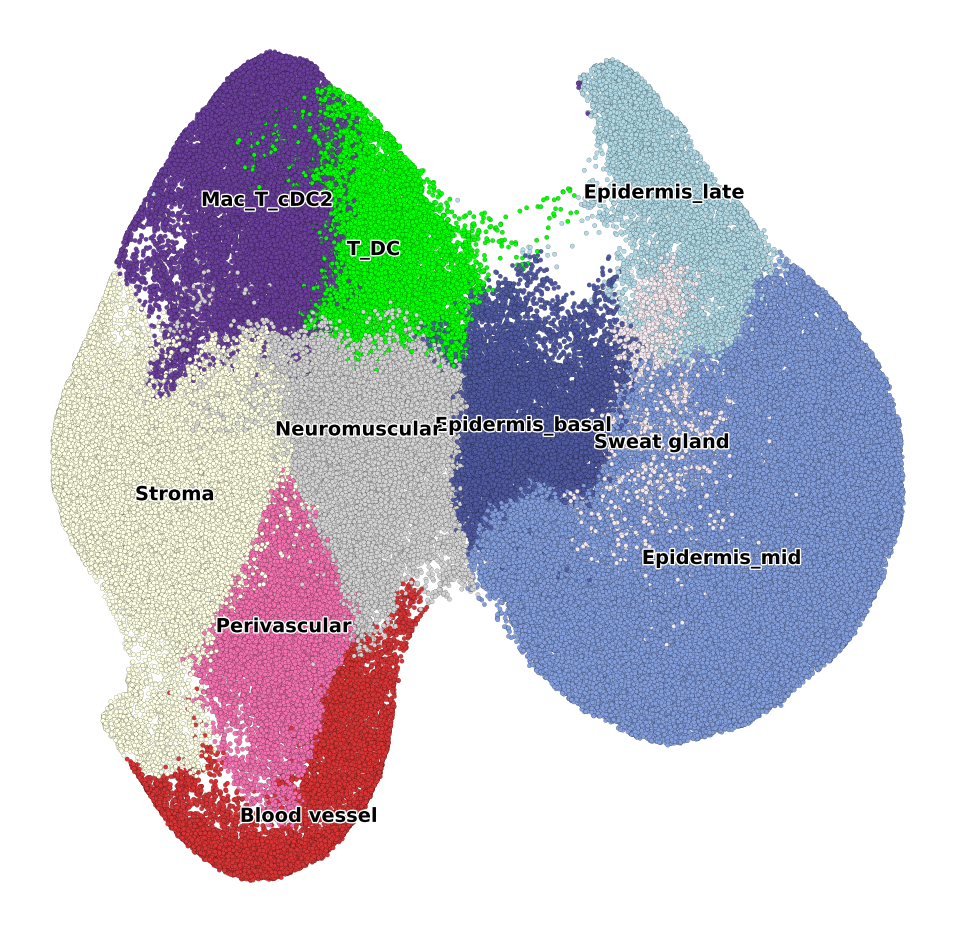

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


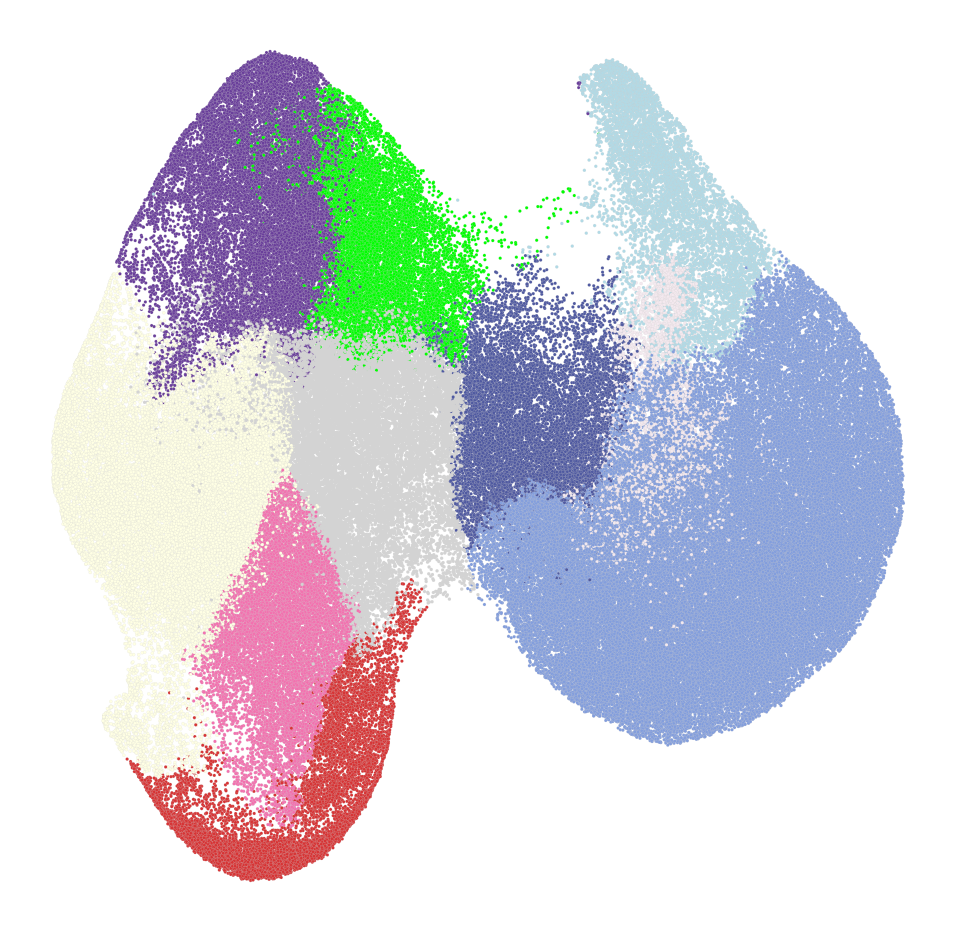

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


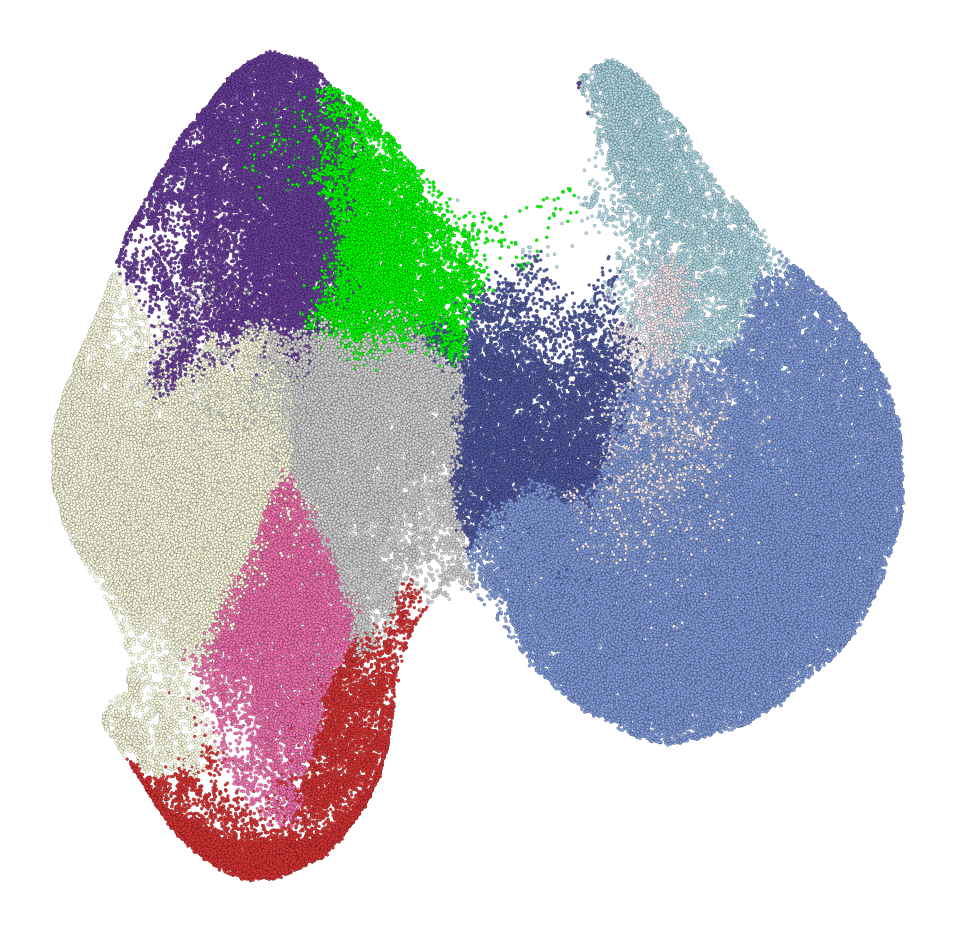

In [11]:
COLORS = {'Mac_T_cDC2': '#6A3F9B',
          'Neuromuscular': '#D3D3D3',
# 'Stroma_deep': "#f6d17a", 
 'T_rich': "#dcb0f2",#'#F4D1A1',
 'Blood vessel': '#d73435',
 'T_DC': '#00FF00',
 'Appendage': "#e28743", #'#94cb72',
 'Sweat gland': '#839edd',
 'Epidermis_late': '#b1dae6',
 'Perivascular': '#f371af',
 'Stroma':'#FFFFE4', # '#f6d17a',
 'Epidermis_mid': '#839edd',
 'Sweat gland': '#f4e9ef',
 'Epidermis_basal': '#505aa1'}
colors=COLORS


adata.obs['spatial_niche']=adata.obs['spatial_niche'].astype('category')
adata.uns['spatial_niche_colors'] = [COLORS[cat] for cat in adata.obs['spatial_niche'].cat.categories]


sc.pl.umap(
    adata,
    color=['spatial_niche'],
    s=40,
legend_loc="on data",
    legend_fontsize=14,
    legend_fontoutline=2,
    title="",
    linewidth=0.1,
            edgecolor="black",

)

sc.pl.umap(
    adata,
    color=['spatial_niche'],
    s=20,
legend_loc=None,
    legend_fontsize=14,
    legend_fontoutline=2,
    title="",
    linewidth=0.1,
            edgecolor="lightgrey",
        save="extrinsic_umap_nolabels.pdf"

   # alpha=0.6

)

sc.pl.umap(
    adata,
    color=['spatial_niche'],
    s=20,
legend_loc=None,
    legend_fontsize=14,
    legend_fontoutline=2,
    title="",
    linewidth=0.1,
            edgecolor="black",
   # alpha=0.6

)

In [12]:
top_n = 5
GROUP = "spatial_niche"

grouped_data = (
    adata.obs.groupby([GROUP, key_celltype])
    .size()
    .reset_index(name="count")
)

grouped_data["total_count"] = grouped_data.groupby(GROUP)["count"].transform("sum")
grouped_data["percentage"] = round((grouped_data["count"] / grouped_data["total_count"]) * 100)

sorted_data = grouped_data.sort_values([GROUP, "count"], ascending=[True, False])
top_contributors = sorted_data.groupby(GROUP).head(top_n)

import pandas as pd
pd.set_option('display.max_rows', None)

top_contributors

/tmp/ipykernel_573628/915313998.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby([GROUP, key_celltype])
/tmp/ipykernel_573628/915313998.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data["total_count"] = grouped_data.groupby(GROUP)["count"].transform("sum")
/tmp/ipykernel_573628/915313998.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_contributors = sorted_data.groupby(GROUP)

,spatial_niche,broad_celltypes,count,total_count,percentage
36,Blood vessel,VE,9177,10906,84.0
25,Blood vessel,Pericyte1_CCL19+,783,10906,7.0
24,Blood vessel,Nonspecific,573,10906,5.0
17,Blood vessel,LE,114,10906,1.0
26,Blood vessel,Pericyte2_CASQ2+,109,10906,1.0
47,Epidermis_basal,KC1-2,1721,11172,15.0
52,Epidermis_basal,KC_HF,1355,11172,12.0
53,Epidermis_basal,KC_Sebocyte,1273,11172,11.0
56,Epidermis_basal,LC,1100,11172,10.0
61,Epidermis_basal,Melanocyte,976,11172,9.0


In [13]:
CATEGORY="spatial_niche"
 

In [14]:
adata_i = adata[adata.obs["spatial_niche"]=="T_DC"]

In [15]:
adata_lesional = adata[adata.obs["Site_status_binary"]=="Lesional"]

In [16]:
ADATA=adata_lesional
CATEGORY="spatial_niche"

sc.tl.rank_genes_groups(ADATA, CATEGORY, method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(ADATA.uns['de_leiden']['names'])
df2.head(5)



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


,Blood vessel,Epidermis_basal,Epidermis_late,Epidermis_mid,Mac_T_cDC2,Neuromuscular,Perivascular,Stroma,Sweat gland,T_DC
0,PLVAP,ITGB4,TMEM45A,ANXA8,CD4,CSRP1,COL4A1,TNXB,ATP1A1,CD3E
1,SHANK3,LAMB3,DMKN,FGFR3,CYBA,MCAM,COL4A2,COL5A1,PYGB,CXCR4
2,ENG,DST,TGM1,DSG3,STAB1,MYLK,COL18A1,TNC,APP,CYBA
3,HSPG2,COL17A1,TGM3,SLC2A1,CLEC10A,FLNC,THY1,CCDC80,ATP5F1A,CD4
4,MYH9,SFRP1,EGR3,TP63,CIITA,SYNPO2,PDGFRB,FSTL1,ATP6V1B1,CCR4


In [17]:
RESULT_DI = {}
for i,select_population in enumerate(list(df2.columns)):
    RESULT_DI[select_population] = []
    


Blood vessel
Epidermis_basal
Epidermis_late
Epidermis_mid
Mac_T_cDC2
Neuromuscular
Perivascular
Stroma
Sweat gland
T_DC


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


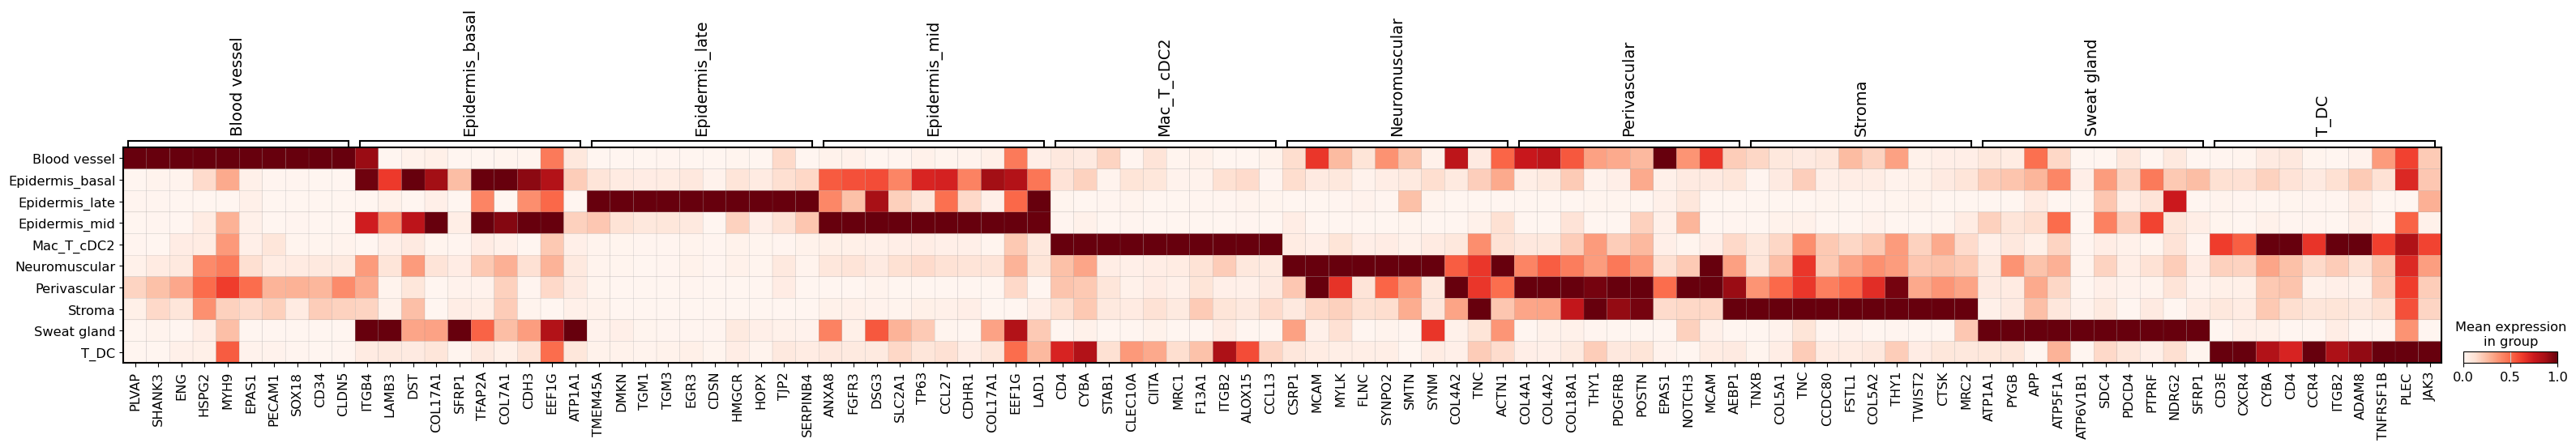

In [18]:
for i,select_population in enumerate(list(df2.columns)):
    select_population = list(df2.columns)[i
                                         ]
    print(select_population)

    genes0 = df2[select_population][:10]
    
    RESULT_DI[select_population] = genes0
    genes1 = df2[select_population][50:100]
    genes2 = df2[select_population][100:150]
    genes3 = df2[select_population][150:200]
    genes4 = df2[select_population][200:250]
    genes5 = df2[select_population][250:300]
    genes6 = df2[select_population][300:350]
    genes7 = df2[select_population][350:400]
    genes8 = df2[select_population][400:450]
sc.pl.matrixplot(
        ADATA,
        RESULT_DI,
        groupby=CATEGORY,
        standard_scale="var",
        dendrogram=False,
    cmap="Reds",
    save="eczema_mcps.pdf"
    )



In [19]:
# genes500= list(df2[select_population][:5000])
# genes500.index('ITK')



# fig 2d

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


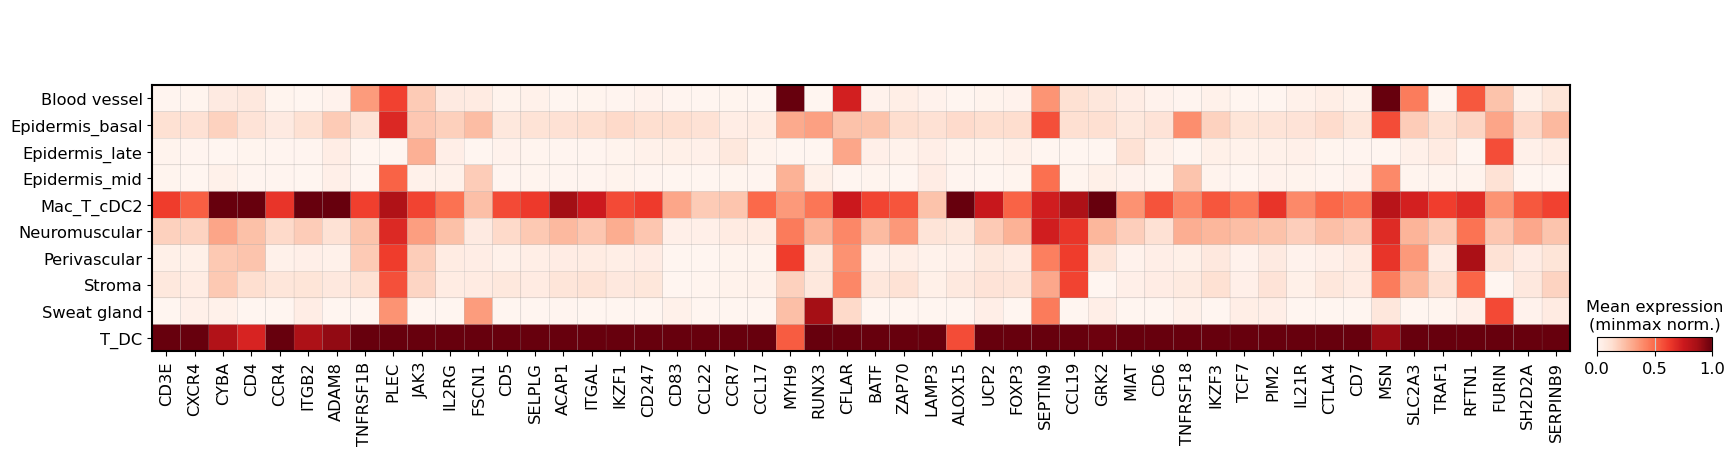

In [20]:
select_population = list(df2.columns)[-1
                                     ]
genes0 = df2[select_population][:50]

sc.pl.matrixplot(
    ADATA,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
    cmap="Reds",
    colorbar_title="Mean expression\n(minmax norm.)",
    save="t_dc_mcp.pdf"

)



In [21]:
# gene_programme = list(df2[select_population][:200])
# import pickle
# with open('eczema_tdc_mcp_top200.pkl', 'wb') as f:
#     pickle.dump(gene_programme, f)

In [22]:

genes0 = df2[select_population][50:150]



In [23]:
genes0 = df2[select_population][150:250]



T_DC


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


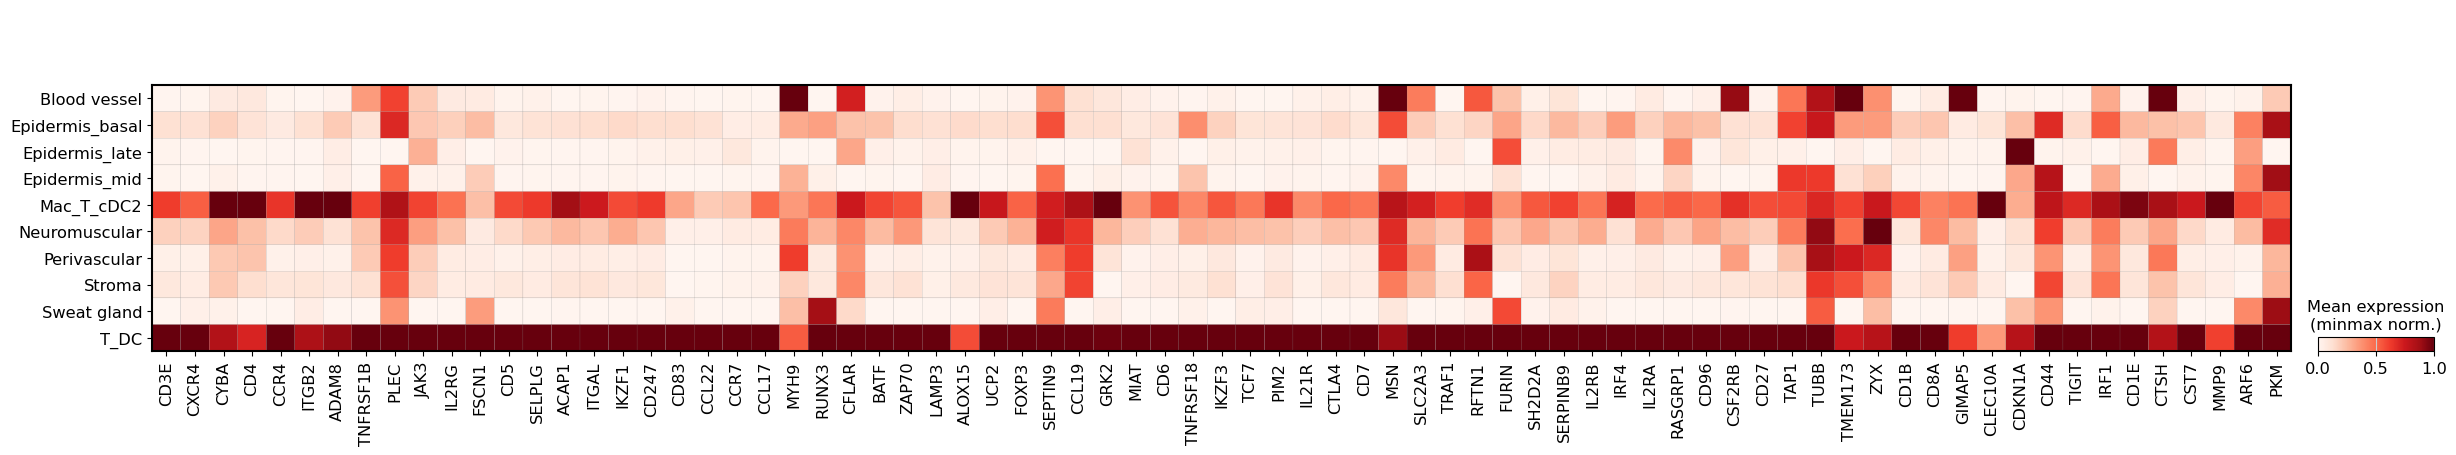

In [24]:
select_population = list(df2.columns)[-1
                                     ]
print(select_population)
genes0 = df2[select_population][:75]


sc.pl.matrixplot(
    ADATA,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
    cmap="Reds",
    colorbar_title="Mean expression\n(minmax norm.)",
    save="t_dc_mcp_75geneversion.pdf"

)



T_DC


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


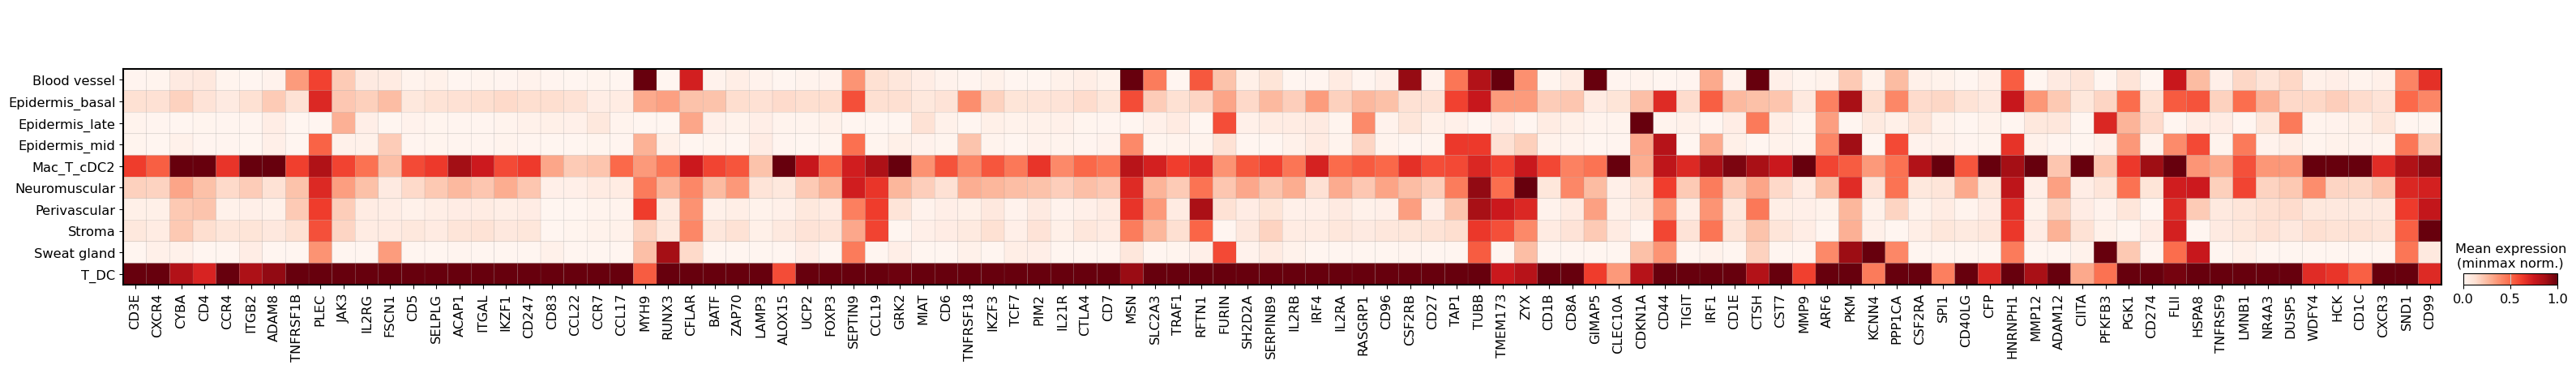

In [25]:
select_population = list(df2.columns)[-1
                                     ]
print(select_population)

genes0 = df2[select_population][:100]


sc.pl.matrixplot(
    ADATA,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
    cmap="Reds",
    colorbar_title="Mean expression\n(minmax norm.)",
    save="t_dc_mcp_100geneslongerversion.pdf"

)



/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


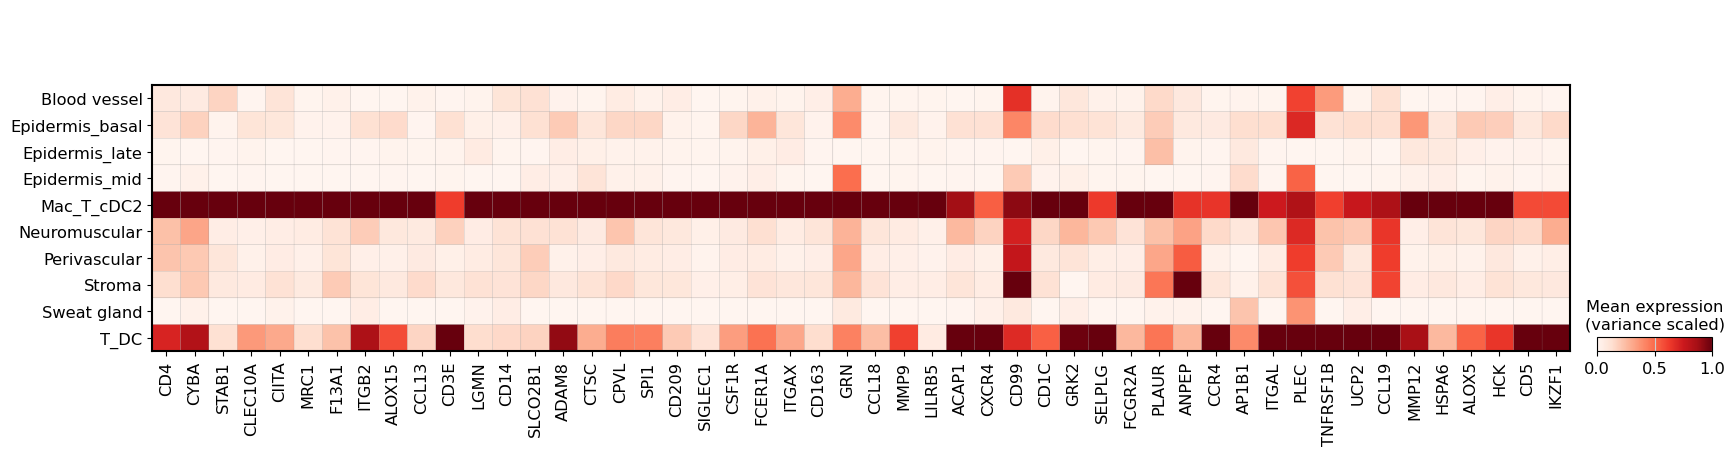

In [26]:
select_population = list(df2.columns)[-6
                                     ]
genes0 = df2[select_population][:50]

sc.pl.matrixplot(
    ADATA,
    genes0,
    groupby=CATEGORY,
    standard_scale="var",
    dendrogram=False,
    cmap="Reds",
    colorbar_title="Mean expression\n(variance scaled)",
   # save="t_dc_mcp.pdf"

)



In [27]:
# import pickle

# with open("mac_cdc2.pkl", "wb") as f:
#     pickle.dump(genes0, f)

In [28]:
adata_i = adata[adata.obs["fine_celltypes"].str.startswith("Treg")].copy()

In [29]:
adata_i.obs["spatial_niche"].value_counts()

spatial_niche
Mac_T_cDC2         2275
T_DC               1804
Neuromuscular       988
Stroma              702
Epidermis_basal     115
Perivascular         95
Epidermis_mid         7
Blood vessel          1
Name: count, dtype: int64

In [30]:
counts = adata_i.obs["spatial_niche"].value_counts()

keep = counts[counts >= 500].index

adata_i = adata_i[adata_i.obs["spatial_niche"].isin(keep)].copy()

In [31]:
# sc.pl.matrixplot(
#     adata_i,
#     ["FOXP3", "LRRC32", "NR4A1" ,"TNFRSF9"], #"STAT5A", "ICOS"
#     groupby="spatial_niche",
#     #standard_scale="var",
#     dendrogram=False,
#     cmap="Reds",
#     colorbar_title="Mean expression\n(minmax norm)",
#     vmax=10
#    # save="t_dc_mcp.pdf"

# )



# fig 2a

BK39_Non-lesional Baseline
BK39_Lesional Baseline
BK21_Lesional Baseline
BK30_Day 14
BK23_Non-lesional Baseline
BK27_Non-lesional Baseline
BK30_Lesional Baseline
BK18_Lesional Baseline
BK22_Lesional Baseline


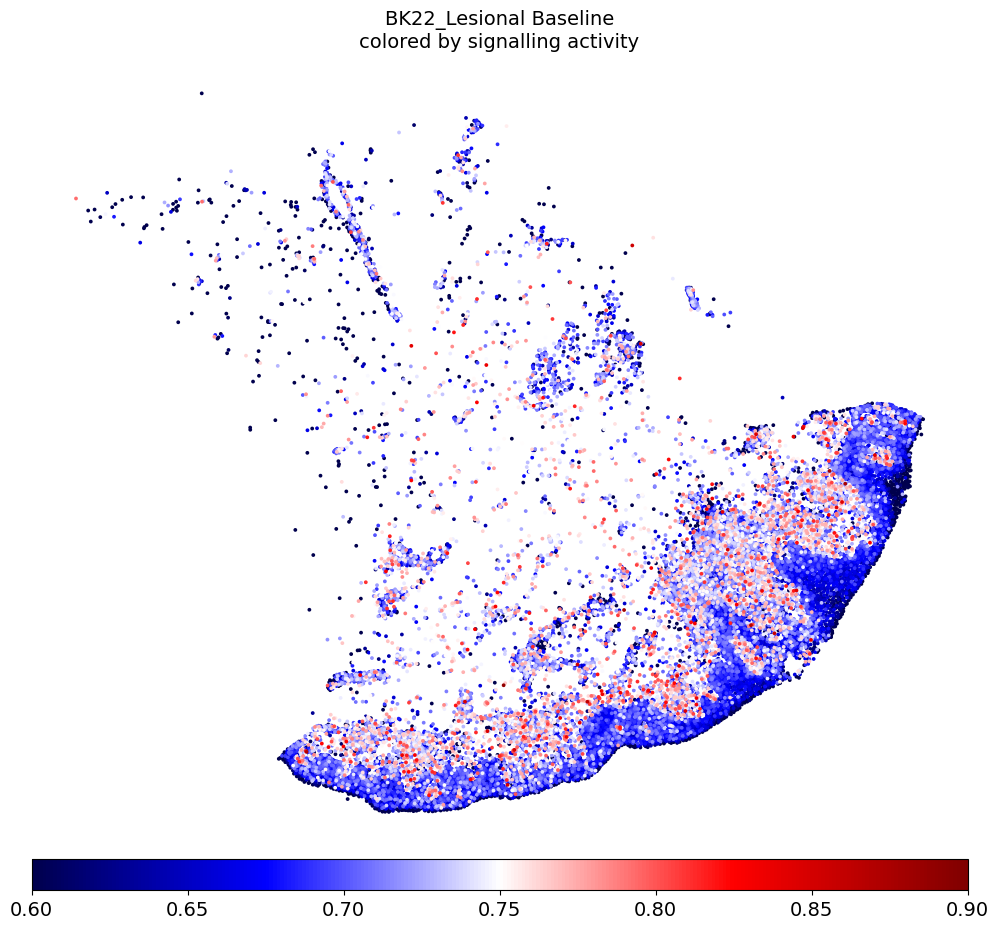

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


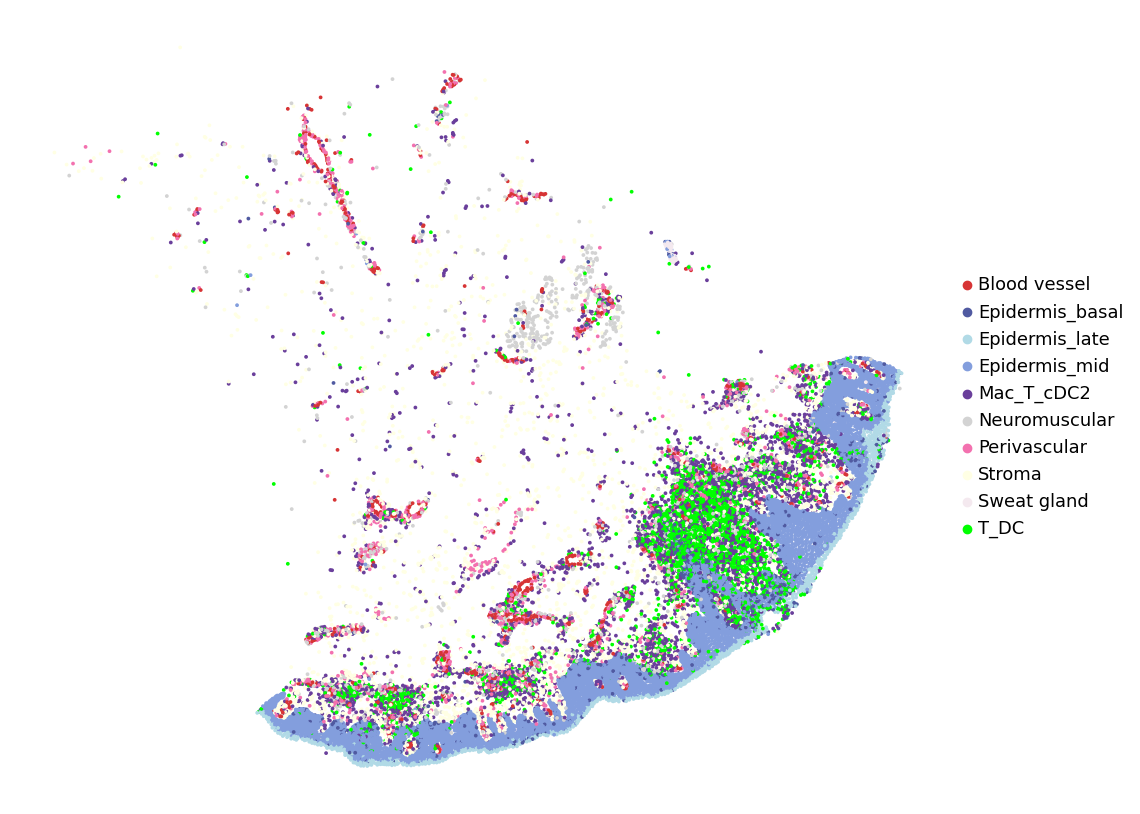

BK23_Lesional Baseline


In [32]:
for slice_id in set(adata.obs['inflow_slice_ID']):
    print(slice_id)
    if slice_id == "BK22_Lesional Baseline":
#         sc.pl.spatial(
#             adata[adata.obs['inflow_slice_ID'] == slice_id],
#             color=['inflow_signaling_activity'],
#             spot_size=20.0,
#             wspace=0.5,
#             cmap='bwr',
#             title=['{}\ncolored by signalling activity'.format(slice_id)],
#             colorbar_loc='bottom',
#             vmin=0.6, vmax=.9
#         )

        sc.pl.spatial(
            adata[adata.obs['inflow_slice_ID'] == slice_id],
            color=['inflow_signaling_activity'],
            spot_size=20.0,
            wspace=0.5,
            cmap='seismic',
            title=['{}\ncolored by signalling activity'.format(slice_id)],
            colorbar_loc='bottom',
                        vmin=0.6, vmax=.9,
                                save="signalling_spatial.pdf"


        )
#         sc.pl.spatial(
#             adata[adata.obs['inflow_slice_ID'] == slice_id],
#             color=['inflow_signaling_activity'],
#             spot_size=20.0,
#             wspace=0.5,
#             cmap='Reds',
#             title=['{}\ncolored by signalling activity'.format(slice_id)],
#             colorbar_loc='bottom',
#                         vmin=0.6

#         )
        sc.pl.spatial(
            adata[adata.obs['inflow_slice_ID'] == slice_id],
            color=['spatial_niche'],
            spot_size=20.0,
            wspace=0.5,
            cmap='Reds',
            title=[''],
            colorbar_loc='bottom',
                        vmin=0.6,
                    save="spatial_domains_spatial.pdf"


        )

In [33]:
colors={'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',

'F2/3: Stroma_PPARG+': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4': '#80ca80',
 'F5': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1-2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#c8cada',
 'KC_HF: Basal': '#006400',
 'KC_HF: IRS+HS': '#abe8bd',
            "'KC_HF: IRS+HS_medulla": "#bff2cd",

 'KC_HF': '#94cb72',
 'KC_SC: LGR6+ACTA2+': "#008080",#'#004444',
 'KCinflamm': '#f4e9ef',
 'KCinflamm_late': '#D49BB1',
 'LC': '#63D7F0',
# 'LC_CCR7+': '#5F3D7D',
 'LC_SLC18A2+': '#3bc1d9',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2_CCL14hi': '#4F2F6D',
 'Mast cell': '#FF1493',
 'Melanocyte': '#6f3a3a',
 'MigDC': '#00FF00',
 'Muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Peri1_CCL19+': '#F7A3C3',
 'Peri2': '#D04A8A',
 'Plasma cell': '#ff5e00',
 'Sebocyte': '#e28743',
 'KC_Sebocyte_inner': '#ffd1a3',
 'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': "#FFE5B4",#'#D1F9F6',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': "#B3FFF0",#'#40E0D0',
   'T': '#F4D1A1',
    'T_Prolif': '#D4B082',
    'Tc': '#8C6A3B',
    'Tc_ITGAEhi_IL13': '#F87A7B',
    'Tnaive/Tcm': '#C6A476',
    'Treg': '#9E7A55',
    'Treg_LRRC32': "#9E5E3A",#'#7E5F43',
 'VE': '#9f1a1a',
 'VE1': '#660000',
 'VE3_SELPhi': '#d73435',
 'cDC1': '#9B70C1',
 'cDC2': '#6F478C',
  'cDC2: MMP12+': '#7D56A3',
 'Schwann': '#3A3A30',
 'nmSchwann': '#0A0A0A',
 'pDC': '#D85B8C',
        
        
        
### scrna only
        'AXL+SIGLEC6+ DC': "#9b4ef5",
'Bcell': "#e14d00",
'Cartilage': "#404040", 
'F4: DP_HHIP+': "#26a83f",
'F6: Inflammatory myofibroblast': "#00ffff",
'F_Fascia': "#000000",
'ILC1_3': "#FFFF00",
'ILC1_NK': "#F4D03F",
'ILC2': "#F1C40F",
'ILC2_inflammatory': "#C79A00",
'KC1': "#3a4e7a",
'KC2': "#505aa1",
'KC_HF: Basal_LGR5+': "#00b300",
'KC_HF: Basal_NPNT+': "#006400",
'KCinflamm_basal': "#f9f3fb",
'KCinflamm_cycling':"#e0c5d2",
'KCinflamm_int': "#f5d3e7",
'LC_CCR7+': "#3bc1a4",
'Mac1': "#6A3F9B",
'MacTREM2_CX3CR1+': "#9D1A80",
'Merkel cell': "#2f2f2f",
'MoDC': "#7F00A2",
"MoDC/cDC2: MMP12+": "#7F00A2",
        
'Mono': "#D8A7FF",
'Mono CD16+': "#E1C6FF",
'NK': "#FFEB3B",
'Neutrophil': "#4D3F8C",
'Satellite muscle': "#F387C7",
'Skeletal muscle': "#F14D8E",
'Tc_IFNGhi': "#F5A600",
'Tc_IL17': "#B84A3D",#"#A75C3E",
'Tc_ZNF683+/γδ': "#D4B082",
'Th': "#F4D1A1",
'Tr1': "#5F452F", 
'cDC2: IL1B+': "#B78FE1",
       
       }

 

In [34]:
 COLORS = {'Mac_T_cDC2': '#6A3F9B',
          'Neuromuscular': '#D3D3D3',
# 'Stroma_deep': "#f6d17a", 
 'T_rich': "#dcb0f2",#'#F4D1A1',
 'Blood vessel': '#d73435',
 'T_DC': '#00FF00',
 'Appendage': "#e28743", #'#94cb72',
 'Sweat gland': '#839edd',
 'Epidermis_late': '#b1dae6',
 'Perivascular': '#f371af',
 'Stroma':'#FFFFE4', # '#f6d17a',
 'Epidermis_mid': '#839edd',
 'Sweat gland': '#f4e9ef',
 'Epidermis_basal': '#505aa1'}
colors=COLORS


adata.obs['spatial_niche']=adata.obs['spatial_niche'].astype('category')
adata.uns['spatial_niche_colors'] = [COLORS[cat] for cat in adata.obs['spatial_niche'].cat.categories]



# fig 2c

/tmp/ipykernel_573628/2380491131.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = ADATA.obs.groupby(["Site_status_binary", "spatial_niche"]).size().unstack(fill_value=0)
/tmp/ipykernel_573628/2380491131.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


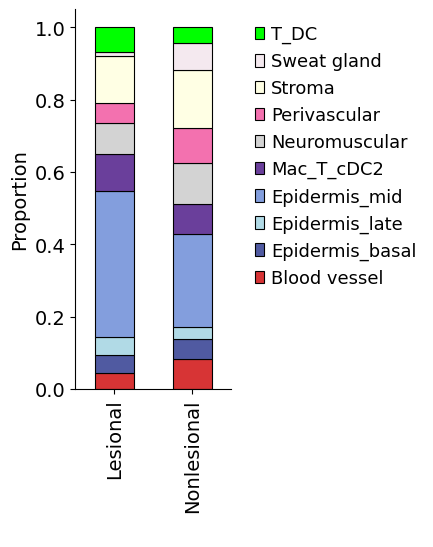

In [35]:
ADATA = adata[adata.obs["Site_status_binary"].isin(["Lesional", "Nonlesional"])]

df = ADATA.obs.groupby(["Site_status_binary", "spatial_niche"]).size().unstack(fill_value=0)
df_norm = df.div(df.sum(axis=1), axis=0)
df_norm = df_norm.loc[:, df_norm.mean() >= 0.002]

color_list = [COLORS.get(cat, "#D3D3D3") for cat in df_norm.columns]

fig, ax = plt.subplots(figsize=(2, 5))
df_norm.plot(kind="bar", stacked=True, color=color_list, edgecolor="black", ax=ax, linewidth=0.8)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("")

plt.xlabel(" ")
plt.ylabel("Proportion")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()




/tmp/ipykernel_573628/1545577487.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = ADATA.obs.groupby(["Site_status_binary", "spatial_niche"]).size().unstack(fill_value=0)
/tmp/ipykernel_573628/1545577487.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


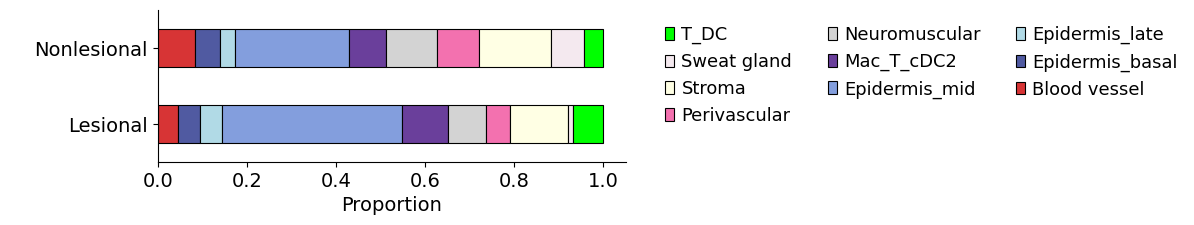

In [36]:
df = ADATA.obs.groupby(["Site_status_binary", "spatial_niche"]).size().unstack(fill_value=0)
df_norm = df.div(df.sum(axis=1), axis=0)
df_norm = df_norm.loc[:, df_norm.mean() >= 0.002]

color_list = [COLORS.get(cat, "#D3D3D3") for cat in df_norm.columns]

fig, ax = plt.subplots(figsize=(6, 2))
df_norm.plot(kind="barh", stacked=True, color=color_list, edgecolor="black", ax=ax, linewidth=0.8)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("")
plt.xlabel("Proportion")
plt.ylabel(" ")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, ncol=3)

plt.tight_layout()
plt.savefig("figures/extrinsic_bysitestatus.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [37]:
RENAME= {'KC1-2': 'KC1-2',
 'Melanocyte': 'Melanocyte',
 'KCinflamm_basal/int': 'KCinflamm_basal/int',
 'KC2/3_cycling': 'KC2/3_cycling',
 'KC3': 'KC3',
 'F3: FRC-like': 'Fibroblast',
 'Mac2': 'Mac',
 'F1: Superficial': 'Fibroblast',
 'Treg': 'T',
 'cDC2': 'cDC2',
 'Nonspecific': 'Nonspecific',
 'VE': 'VE',
 'T': 'T',
 'Mast cell': 'Mast cell',
 'F2: Universal': 'Fibroblast',
 'LE': 'LE',
 'cDC1': 'cDC1',
 'F2/3: Stroma_PPARG+': 'Fibroblast',
 'MigDC': 'MigDC',
 'Tc_IL13': 'T',
 'Smooth muscle': 'Smooth muscle',
 'KC_HF': 'KC_HF',
 'KC_Sebocyte': 'KC_HF',
 'Sweat gland channel': 'Sweat gland',
 'Adipocyte': 'Adipocyte',
 'pDC': 'pDC',
 'Pericyte1_CCL19+': 'Pericyte',
 'KC5': 'KC5',
 'KCinflamm_late': 'KCinflamm_late',
 'KC4': 'KC4',
 'Schwann': 'Schwann',
 'Mac2_CCL14hi': 'Mac',
 'LC': 'LC',
 'MoDC/cDC2': 'MoDC/cDC2',
 'T_Prolif': 'T',
 'Sweat gland': 'Sweat gland',
 'Pericyte2_CASQ2+': 'Pericyte',
 'F4: Hair follicle-associated': 'Fibroblast',
 'F5: Schwann-like': 'Fibroblast',
 'Plasma cell': 'Plasma cell'}

adata.obs["key_celltype_new"] = adata.obs[key_celltype].map(RENAME)

COLORS = {
    'KC1-2': '#505aa1',
    'Melanocyte': '#6f3a3a',
    'KCinflamm_basal/int': '#f4e9ef',
    'KC2/3_cycling': '#007FFF',
    'KC3': '#839edd',
    'Fibroblast': '#FFFFE4',
    'Mac': '#1B03A3',
    'T': '#E0A87F',
    'cDC2': '#6F478C',
    'Nonspecific': '#D3D3D3',
    'VE': '#d73435',
    'Mast cell': '#FF5F00',
    'LE': '#FFFF00',
    'cDC1': '#9B70C1',
    'MigDC': '#00FF00',
    'Smooth muscle': '#f371af',
    'KC_HF': '#abe8bd',
    'KC_Sebocyte': '#ffd1a3',
    'Sweat gland channel': '#2DA8A0',
    'Adipocyte': '#FFFFFF',
    'pDC': '#D85B8C',
    'Pericyte': '#F7A3C3',
    'KC5': '#c8cada',
    'KCinflamm_late': '#D49BB1',
    'KC4': '#b1dae6',
    'Schwann': '#0A0A0A',
    'LC': '#3bc1d9',
    'MoDC/cDC2': '#7F00A2',
    'Sweat gland': '#FFEDD5',
    'Plasma cell': '#ff5e00'
}


adata.obs["key_celltype_new"]=adata.obs["key_celltype_new"].astype('category')
color_palette = [COLORS[cell_type] for cell_type in adata.obs["key_celltype_new"].cat.categories]


# supp fig b

/tmp/ipykernel_573628/2231643874.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df = ADATA.obs.groupby(["spatial_niche", "key_celltype_new"]).size().unstack(fill_value=0)
/tmp/ipykernel_573628/2231643874.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


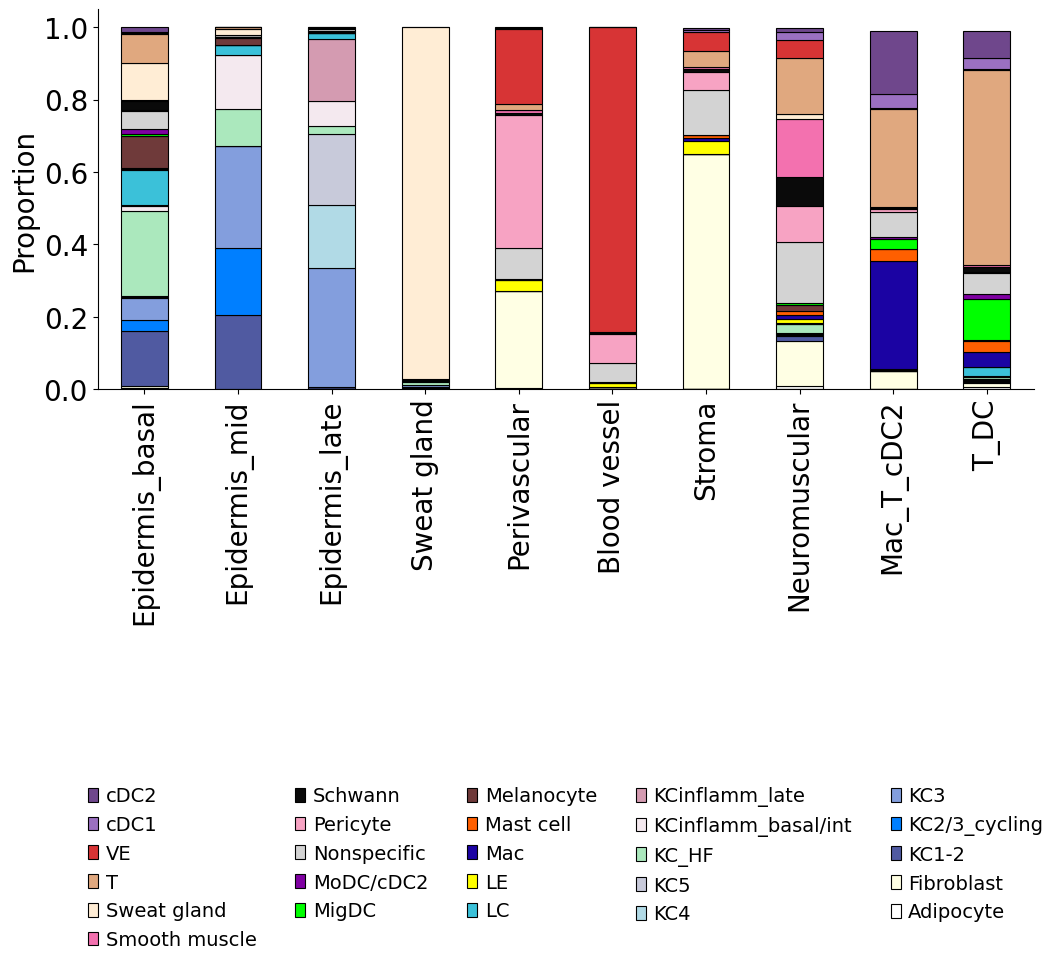

In [38]:
ADATA = adata
FONTSIZE = 20

ORDER = [
    'Epidermis_basal',
    'Epidermis_mid',
    'Epidermis_late',
    'Sweat gland',
    'Perivascular',
    'Blood vessel',
    'Stroma',
    'Neuromuscular',
    'Mac_T_cDC2',
    'T_DC',
]

df = ADATA.obs.groupby(["spatial_niche", "key_celltype_new"]).size().unstack(fill_value=0)
df_norm = df.div(df.sum(axis=1), axis=0)
df_norm = df_norm.loc[:, df_norm.mean() >= 0.002]
df_norm = df_norm.reindex(ORDER)

color_list = [COLORS.get(cat, "#D3D3D3") for cat in df_norm.columns]

fig, ax = plt.subplots(figsize=(12, 5))

df_norm.plot(kind="bar", stacked=True, color=color_list, edgecolor="black", ax=ax, linewidth=.8, width=0.5)

plt.xticks(fontsize=FONTSIZE, rotation=90)
plt.yticks(fontsize=FONTSIZE)
plt.xlabel(" ", fontsize=10)
plt.ylabel("Proportion", fontsize=FONTSIZE)
ax.legend(fontsize=14)

ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_title("")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="", bbox_to_anchor=(0.5, -1), loc="upper center", frameon=False, ncol=5, fontsize=14)

ax.set_xticklabels(ORDER, rotation=90, fontsize=FONTSIZE)

plt.tight_layout()
plt.savefig("eczema_domain_cellcomposition.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [39]:
def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST




# T cells

In [40]:
if not DATA_PREPARED_T:
    adata_i = adata[adata.obs[key_celltype].str.startswith("T")]
    M_BAR_METRIC = 'inflow_Xbar_spl'
    adata_i
    
else:
    print("load prepped data")
    adata_i=sc.read_h5ad('/nfs/team361/ls34/inflow/final_adatas/adata_tcells.h5ad')
    COLOR = {
        'Dermis': '#EFE8D7',
        'Superficial': '#F87A7B'
    }
    adata_i.obs["t_cellsubtypes"] =adata_i.obs["t_cellsubtypes"].astype('category')
    adata_i.uns["t_cellsubtypes_colors"] = [COLOR[subtype] for subtype in adata_i.obs['t_cellsubtypes'].cat.categories]
    
    
    
    


load prepped data


In [41]:
if not DATA_PREPARED_T:

    sc.pp.neighbors(adata_i, use_rep = M_BAR_METRIC, 
                    metric = "euclidean", n_neighbors=20)#key_added=neighbor_id)
    sc.tl.umap(adata_i, min_dist=0.1) #neighbor_key=)


    sc.pl.umap(adata_i,  
               color=[ "NICHE_NAMES", key_celltype],
               s=200,legend_loc="on data",
               legend_fontsize=8)

    RES=0.1
    sc.tl.leiden(adata_i, #restrict_to=(CATEGORY,subset_cluster), 
                 resolution=RES, random_state=1, key_added=f'leiden_res{RES}') #neighbors_key='neighbor_30')


    sc.pl.umap(adata_i,  
               color=[ key_celltype, f"leiden_res{RES}"],
               s=200,legend_loc="on data",
               legend_fontsize=8
              )

else:
    print("skip as data prepared")

skip as data prepared


In [42]:


if not DATA_PREPARED_T:

    RENAME  = {'0': "Dermis",
               '1': "Dermis",
               '2': "Superficial" 
              }

    adata_i.obs["t_cellsubtypes"] =adata_i.obs[ f"leiden_res{RES}"].map(RENAME)#.fillna(adata_i.obs[ f"leiden_res{RES}"])
    sc.pl.umap(adata_i,  
               color=["t_cellsubtypes"],
               s=200,legend_loc="on data",
               legend_fontsize=8
              )

    # in this plot, how can i colour:
    #        'Dermis': '#8C6A3B',
    #     'Superficial': '#F87A7B',



# fig 2j

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


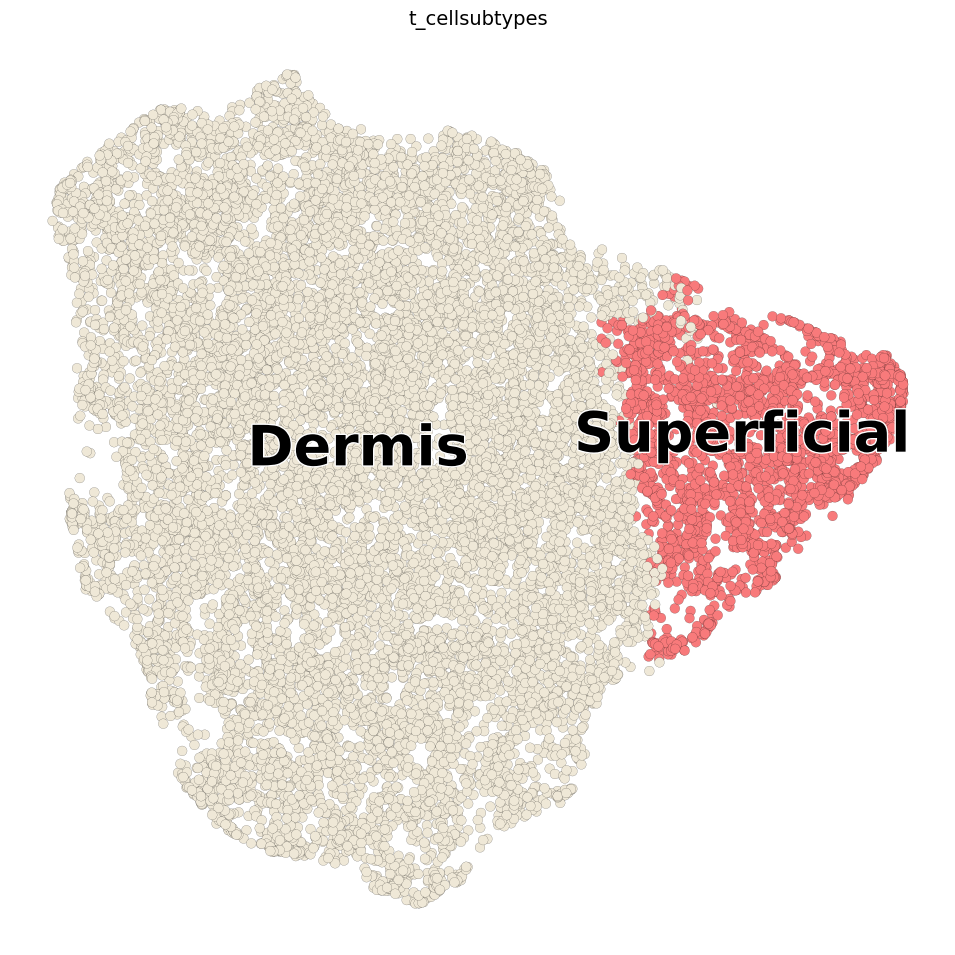

In [43]:

sc.pl.umap(
    adata_i,  
    color=["t_cellsubtypes"],
    s=200,
    legend_loc="on data",
    legend_fontsize=40,
    legend_fontoutline=2,
                edgecolor="black",
            linewidth=0.1,
    save = "umap_tcells_spatialdomain.pdf"
)

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


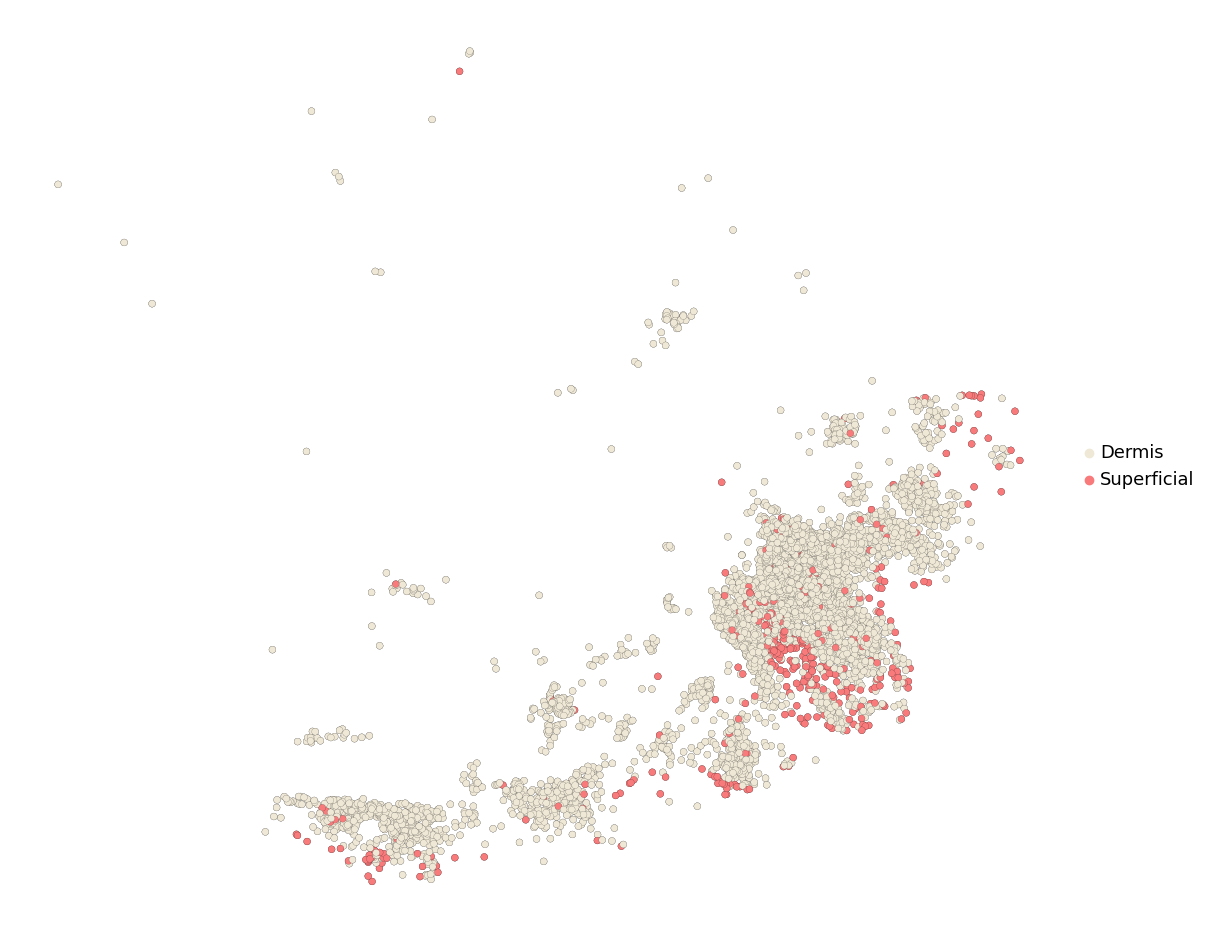

In [44]:

# COLOR = {
#     'Dermis': '#D8C59A',
#     'Superficial': '#F87A7B'
# }
# color_palette = ListedColormap([COLOR[k] for k in COLOR.keys()])
for x in adata_i.obs["Sanger patient ID"].unique():
    adata_ii = adata_i[adata_i.obs["Sanger patient ID"] == x]
    if x == "BK22":
        sq.pl.spatial_scatter(
            adata_ii,
            library_id="spatial",
            shape=None,
            color='t_cellsubtypes',  
            size=100,
            title='',
            edgecolor="black",
            linewidth=0.1,
                save = "umap_tcells_spatialdomain_forhande.pdf"

            #palette=color_palette  
        )

In [45]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(12, 12))

/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


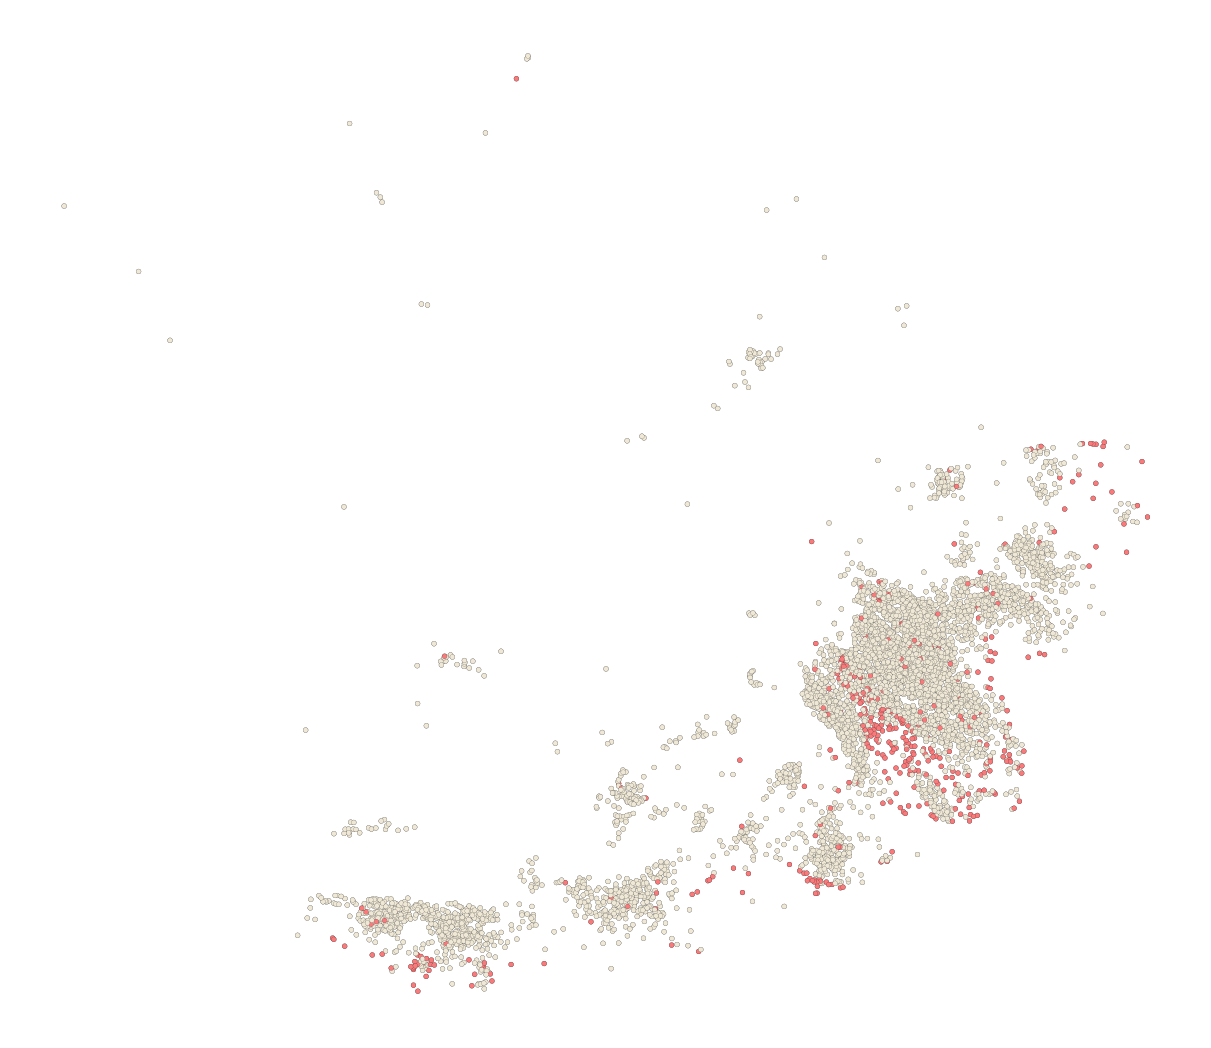

In [46]:

# COLOR = {
#     'Dermis': '#D8C59A',
#     'Superficial': '#F87A7B'
# }
# color_palette = ListedColormap([COLOR[k] for k in COLOR.keys()])
for x in adata_i.obs["Sanger patient ID"].unique():
    adata_ii = adata_i[adata_i.obs["Sanger patient ID"] == x]
    if x == "BK22":
        sq.pl.spatial_scatter(
            adata_ii,
            library_id="spatial",
            shape=None,
            color='t_cellsubtypes',  
            size=50,
            title='',
            edgecolor="black",
            linewidth=0.1,

            legend_loc=None,
                save = "umap_tcells_spatialdomain_forhande_smaller.pdf"

            #palette=color_palette  
        )